# 05 — Mesures finales de l'agent : le scénario de démo rejoué et chronométré

Le scénario de soutenance (`docs/08-script-demo.md`) sert de banc de mesure — chaque séquence est rejouée contre `/agent/ask` en conditions réelles (pile compose + Ollama hôte, `./demarrer.sh`).

Mesures produites : **coups illégaux** (objectif 0, arbitre python-chess), **latence agent p50/p95** (objectif p95 < 8 s), **abstention de bout en bout** (piège scandinave), **coût LLM** (objectif < 5 €).

In [1]:
import statistics
import time

import chess
import httpx

API = "http://localhost:8000/api/v1"

# Le parcours du doc 08 : premier coup → Italienne → sortie de théorie, + position de secours.
SCENARIO = {
    "seq1 — 1.e4": "rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq e3 0 1",
    "seq2 — Italienne 3.Fc4": "r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5N2/PPPP1PPP/RNBQK2R b KQkq - 3 3",
    "seq4 — hors théorie 4.g4?!": "r1bqk1nr/pppp1ppp/2n5/2b1p3/2B1P1P1/5N2/PPPP1P1P/RNBQK2R b KQkq g3 0 4",
    "secours — Sicilienne": "rnbqkbnr/pp1ppppp/8/2p5/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2",
}

httpx.get(f"{API}/healthcheck", timeout=5).json()

{'status': 'ok',
 'service': 'backend',
 'version': '0.5.0',
 'fastapi': '0.141.1',
 'mongo_cache': 'ok'}

## 1. Rejeu du scénario — 3 répétitions par position (le chrono voit cache froid puis chaud)

In [2]:
reponses, chronos_tous = {}, {}
for nom, fen in SCENARIO.items():
    chronos = []
    for _ in range(3):
        debut = time.perf_counter()
        r = httpx.post(f"{API}/agent/ask", json={"fen": fen}, timeout=120)
        r.raise_for_status()
        chronos.append(time.perf_counter() - debut)
    reponses[nom], chronos_tous[nom] = r.json(), chronos
    rep = reponses[nom]
    branche = "théorie" if rep["in_theory"] else "moteur"
    print(f"{nom:30s} {branche:8s} {min(chronos):5.2f}–{max(chronos):5.2f} s  "
          f"{len(rep['theory_moves'])} coups · {len(rep['rag_chunks'])} fiches · "
          f"{len(rep['videos'])} vidéos · {len(rep['errors'])} incident(s)")

seq1 — 1.e4                    théorie   3.84– 6.27 s  12 coups · 5 fiches · 3 vidéos · 0 incident(s)


seq2 — Italienne 3.Fc4         théorie   4.16– 5.29 s  12 coups · 5 fiches · 3 vidéos · 0 incident(s)


seq4 — hors théorie 4.g4?!     moteur    2.63– 3.88 s  0 coups · 0 fiches · 0 vidéos · 0 incident(s)


secours — Sicilienne           théorie   4.21– 4.53 s  12 coups · 5 fiches · 3 vidéos · 0 incident(s)


In [3]:
# Séquence 3 du script : la question libre de l'élève sur la position italienne.
debut = time.perf_counter()
question = httpx.post(
    f"{API}/agent/ask",
    json={"fen": SCENARIO["seq2 — Italienne 3.Fc4"], "question": "Pourquoi joue-t-on 3.Fc4 ?"},
    timeout=120,
).json()
chronos_tous["seq3 — question libre"] = [time.perf_counter() - debut]
print(question["answer"][:400])
print("\nSources :", " · ".join(question["sources"]))

Salut ! On va voir pourquoi les Blancs jouent le Fou en c5. C'est un coup très populaire dans la Partie Italienne, comme tu peux le lire dans les faits fournis : il y a plus de 21 000 parties où on joue ce mouvement avant d'autres options. Le but est souvent de contrôler le centre et de préparer une attaque contre l'aile des Noirs en ouvrant la diagonale du Fou blanc. C'est un choix classique qui 

Sources : Base masters — Lichess Opening Explorer (CC0) · Corpus (CC BY-SA) — https://fr.wikipedia.org/wiki/Partie_italienne_Giuoco_Piano · Corpus (CC BY-SA) — https://fr.wikipedia.org/wiki/Gambit_Blackburne


In [4]:
# Séquence 4 : la sortie de théorie doit basculer branche moteur avec une éval négative (g4?!).
hors = reponses["seq4 — hors théorie 4.g4?!"]
assert hors["in_theory"] is False and hors["engine_eval"] is not None
ev = hors["engine_eval"]
print(f"Routeur → moteur · éval {ev['cp']} cp (profondeur {ev['depth']}) · suite {ev['best_line']}")

Routeur → moteur · éval -147 cp (profondeur 16) · suite ['Nf6', 'Nc3', 'Nxg4', 'Rf1', 'd6', 'd3', 'Na5', 'Bb3']


## 2. `[MESURE]` Coups illégaux — l'arbitre python-chess repasse derrière TOUT ce que l'agent affiche

In [5]:
controles, illegaux = 0, 0
for nom, rep in list(reponses.items()) + [("seq3 — question libre", question)]:
    board = chess.Board(rep["fen"])
    for coup in rep["theory_moves"]:  # les coups recommandés par la théorie
        controles += 1
        if chess.Move.from_uci(coup["uci"]) not in board.legal_moves:
            illegaux += 1
            print(f"ILLÉGAL : {coup} sur {nom}")
    if rep["engine_eval"]:  # la meilleure suite du moteur, rejouée coup à coup
        rejeu = chess.Board(rep["fen"])
        for san in rep["engine_eval"]["best_line"]:
            controles += 1
            try:
                rejeu.push(rejeu.parse_san(san))
            except ValueError:
                illegaux += 1
                print(f"ILLÉGAL : {san} sur {nom}")
print(f"\n[MESURE] {controles} coups affichés contrôlés → {illegaux} illégal(aux)")
assert illegaux == 0


[MESURE] 56 coups affichés contrôlés → 0 illégal(aux)


## 3. `[MESURE]` Latence agent p50 / p95 — toutes requêtes confondues (froid + chaud)

In [6]:
echantillons = sorted(t for chronos in chronos_tous.values() for t in chronos)
p50 = statistics.median(echantillons)
p95 = echantillons[max(0, round(0.95 * len(echantillons)) - 1)]
print(f"[MESURE] {len(echantillons)} requêtes · p50 {p50:.2f} s · p95 {p95:.2f} s "
      f"(objectif p95 < 8 s : {'✅ tenu' if p95 < 8 else '❌ dépassé'})")

[MESURE] 13 requêtes · p50 4.21 s · p95 6.27 s (objectif p95 < 8 s : ✅ tenu)


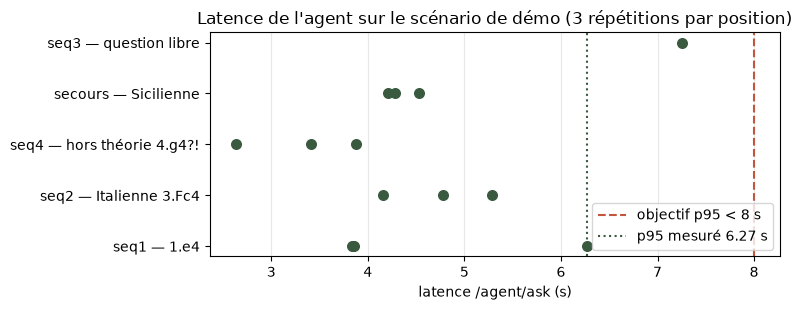

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt

noms = list(chronos_tous)
fig, ax = plt.subplots(figsize=(8, 3.2))
for i, nom in enumerate(noms):
    points = chronos_tous[nom]
    ax.scatter(points, [i] * len(points), s=48, color="#3a5a40", zorder=3)
ax.axvline(8, color="#c1553d", linestyle="--", label="objectif p95 < 8 s")
ax.axvline(p95, color="#3a5a40", linestyle=":", label=f"p95 mesuré {p95:.2f} s")
ax.set_yticks(range(len(noms)), noms)
ax.set_xlabel("latence /agent/ask (s)")
ax.set_title("Latence de l'agent sur le scénario de démo (3 répétitions par position)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(Path("../notebooks/figures/06-latences-agent.png"), dpi=150)
plt.show()

## 4. `[MESURE]` Abstention de bout en bout — le piège scandinave traverse tout le graphe

Le gold set a montré (notebook 04) qu'un seuil seul laisse passer ce piège adjacent. Ici on vérifie la **défense en profondeur** : que fait l'agent COMPLET quand l'élève pose la question hors corpus ?

In [8]:
# 1.e4 d5 2.exd5 Dxd5 3.Cc3 Da5 — la Scandinave, ouverture ABANDONNÉE au manifeste signé.
FEN_SCANDINAVE = "rnb1kbnr/ppp1pppp/8/q7/8/2N5/PPPP1PPP/R1BQKBNR w KQkq - 2 4"
piege = httpx.post(
    f"{API}/agent/ask",
    json={"fen": FEN_SCANDINAVE, "question": "Quelles sont les idées de la défense scandinave ?"},
    timeout=120,
).json()
print(f"Fiches RAG remontées : {len(piege['rag_chunks'])}")
print(f"Sources : {piege['sources']}")
print(f"\nRéponse :\n{piege['answer']}")

Fiches RAG remontées : 5
Sources : ['Base masters — Lichess Opening Explorer (CC0)', 'Corpus (CC BY-SA) — https://fr.wikipedia.org/wiki/D%C3%A9fense_sicilienne', 'Corpus (CC BY-SA) — https://fr.wikipedia.org/wiki/D%C3%A9fense_est-indienne', 'Corpus (CC BY-SA) — https://fr.wikipedia.org/wiki/D%C3%A9fense_fran%C3%A7aise']

Réponse :
Salut ! Voici les faits sur cette position : c'est aux Blancs, on joue dans une Scandinaise (B01), et la théorie recommande d'abord jouer **d4** ou le coup du Fou en **c4**. Les grands maîtres ont joué ces coups très souvent. Je ne peux pas t'apprendre les idées de cette ouverture car tes faits mentionnent des extraits sur la défense sicilienne, l'est-indienne et la française mais rien qui explique ce que fait vraiment la Scandinaise !

Sources : Base masters — Lichess Opening Explorer (CC0) · Corpus (CC BY-SA) — https://fr.wikipedia.org/wiki/D%C3%A9fense_sicilienne · Corpus (CC BY-SA) — https://fr.wikipedia.org/wiki/D%C3%A9fense_est-indienne · Corpus (CC BY-

**Verdict (constat reproductible du banc)** : la défense en profondeur est **à moitié tenue**. Le LLM n'invente pas d'« idées de la scandinave » — il se rabat sur les seuls faits vérifiés (les statistiques masters de la position, qui est réellement jouée). MAIS, sans seuil d'abstention en production, les **5 fiches adjacentes** (sicilienne, est-indienne, française) remontent et sont **citées en sources** — une citation trompeuse pour l'élève. Cette mesure alimente la décision ouverte du seuil (rappel ⏳ item 1) : c'est exactement le cas que le seuil ~0,55 + règle d'honnêteté du prompt doit couvrir.

## 5. `[MESURE]` Coût LLM — le titulaire est local, la facture est nulle

D1 (révisée le 22/08) : synthèse par **qwen3.5:4b via Ollama, sur la machine** — aucun jeton facturé, ni en dev, ni en démo. Le seul fournisseur payant (Anthropic) est une **option** jamais activée au POC (`LLM_PROVIDER=ollama`). Coût facturé : **0,00 €** (objectif < 5 €). Pour l'étude d'échelle (partie 2) : une réponse ≈ 1 200 tokens d'entrée + ~250 de sortie → au tarif Haiku 4.5 (1 $/M entrée, 5 $/M sortie), le **coût marginal cloud serait ≈ 0,25 centime par réponse** — l'ordre du centime annoncé.

In [9]:
requetes_llm = len(echantillons) + 1  # scénario + piège — toutes servies par Ollama local
cout_cloud_equivalent = requetes_llm * (1200 * 1 + 250 * 5) / 1_000_000  # $ si Haiku 4.5
print(f"[MESURE] {requetes_llm} appels LLM au banc · facturé 0,00 € "
      f"(équivalent cloud Haiku : ~{cout_cloud_equivalent:.3f} $)")

[MESURE] 14 appels LLM au banc · facturé 0,00 € (équivalent cloud Haiku : ~0.034 $)
